In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
df=pd.read_csv(r"C:\Users\SUJAN SURE\OneDrive\Desktop\AIML-3\virtual\Scripts\Preprocessed data.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M


In [24]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [25]:
X=df.drop("salary",axis=1)
y=df["salary"]
X=pd.get_dummies(X,drop_first=True)
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",X_train.shape)
print("Testing Features: ",X_test.shape)
print("Training Target: ",y_train.shape)
print("Testing Target: ",y_test.shape)
print("\nTraining Data")
print(X_train.head())
print("\n Testing Data")
print(X_test.head())

Training Features:  (1079, 232)
Testing Features:  (270, 232)
Training Target:  (1079,)
Testing Target:  (270,)

Training Data
      work_year  salary_in_usd  remote_ratio  experience_level_EX  \
755        2022         130000           100                False   
109        2022         140000           100                False   
1040       2021         130000             0                False   
548        2022         260000           100                False   
1341       2021         135000           100                False   

      experience_level_MI  experience_level_SE  employment_type_FL  \
755                  True                False               False   
109                 False                 True               False   
1040                False                 True               False   
548                 False                 True               False   
1341                False                 True               False   

      employment_type_FT  employment_

In [26]:
Y=df["salary_in_usd"]
X=df["salary"]
m=((X - X.mean()) * (Y - Y.mean())).sum() / ((X-X.mean())**2).sum()
c=Y.mean()-m* X.mean()
Y_pred=m*X+c
Y_pred=Y_pred.round()
print("Slope= ",m)
print("Intercept= ",c)


Slope=  -0.00016667693869324297
Intercept=  121666.76557578868


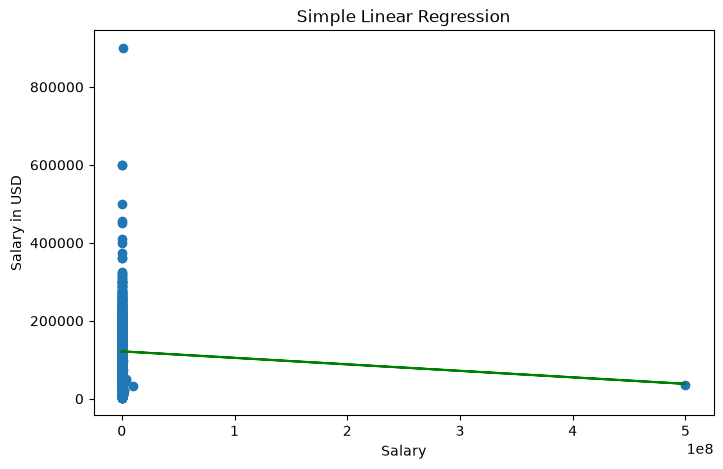

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color="green")
plt.title("Simple Linear Regression")
plt.xlabel("Salary")
plt.ylabel("Salary in USD")
plt.show()

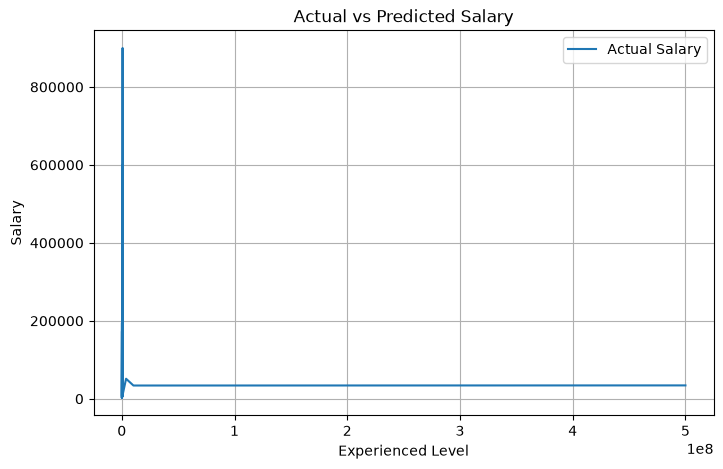

In [28]:
import matplotlib.pyplot as plt
sorted_data=pd.DataFrame({
    "X":X,
    "Actual":Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual Salary")
plt.title("Actual vs Predicted Salary")
plt.xlabel("Experienced Level")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)
plt.show()

Intercept (b0): 120857.64168103693
Slope (b1): -0.00016992302347636866

Regression Equation:
salary_in_usd = 120857.64 + (-0.00) × salary
   Salary  Actual Salary (USD)  Predicted Salary (USD)
0   91860                91860                  120842
1  145000               145000                  120833
2  315000                58390                  120804
3   40000                42801                  120851
4  170000               135596                  120829
5  125000               125000                  120836
6  180000               192606                  120827
7  190000               190000                  120825
8   48000                51361                  120849
9  228600               228600                  120819


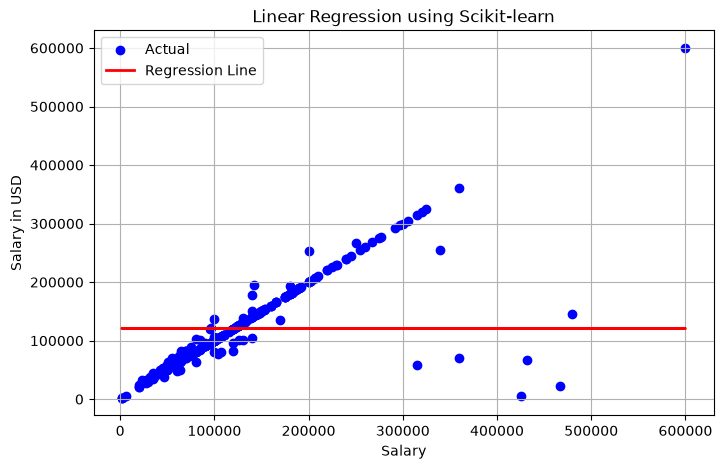

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv(r"C:\Users\SUJAN SURE\OneDrive\Desktop\AIML-3\virtual\Scripts\Preprocessed data.csv")

# Feature (Independent variable)
X = df[["salary"]]

# Target (Dependent variable)
y = df["salary_in_usd"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Print model parameters
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

print("\nRegression Equation:")
print(f"salary_in_usd = {model.intercept_:.2f} + ({model.coef_[0]:.2f}) × salary")

# Predict
y_pred = model.predict(X_test)

# Round predictions
y_pred = np.round(y_pred).astype(int)

# Results table
result = pd.DataFrame({
    "Salary": X_test["salary"].values,
    "Actual Salary (USD)": y_test.values,
    "Predicted Salary (USD)": y_pred
})

print(result.head(10))

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X_test["salary"],
    y_test,
    color="blue",
    label="Actual"
)

plt.plot(
    X_test["salary"],
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Linear Regression using Scikit-learn")
plt.xlabel("Salary")
plt.ylabel("Salary in USD")
plt.legend()
plt.grid(True)

plt.show()